


# 1. Natural language processing




In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q http://archive.apache.org/dist/spark/spark-3.1.1/spark-3.1.1-bin-hadoop3.2.tgz
!tar xf spark-3.1.1-bin-hadoop3.2.tgz
!pip install -q findspark


In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.1.1-bin-hadoop3.2"
import time
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf
spark = SparkSession.builder.master("local[8]").getOrCreate()
spark.conf.set("spark.sql.repl.eagerEval.enabled", True) # Property used to format output tables better
spark
sc = SparkContext.getOrCreate(spark.conf)


In [4]:
num_cores = sc.defaultParallelism
print("Number of CPU cores:", num_cores)


Number of CPU cores: 8


In [5]:
import re


# 1-1

# الف

In [6]:
# Downloading stopwords
import nltk
nltk.download('stopwords')

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Printing the word counts
for word, count in word_counts_list:
    print(f"{word}: {count}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Streaming output truncated to the last 5000 lines.
stream: 11
solid: 12
nd: 5
sicily: 1
suggestions: 8
standing: 77
specimen: 7
excused: 16
persuadableness: 1
shells: 2
harrison: 1
fetch: 32
cheerfully: 20
worded: 3
issue: 8
congratulations: 26
displeasure: 34
peremptorily: 2
inarticulately: 1
reproaches: 10
infatuation: 9
treatment: 30
hopeful: 4
unprepared: 5
similes: 1
discussed: 9
estate: 77
bearers: 2
comfort: 301
thoughtful: 21
dissuade: 11
campbell: 56
sam: 11
port: 6
mess: 3
seasons: 3
drawer: 10
prettily: 9
regularity: 6
dawdle: 1
clatter: 1
lascelle: 1
catch: 45
indefensible: 1
equals: 6
whither: 15
passable: 3
deckers: 1
sue: 2
deserving: 24
diversified: 3
deficiencies: 7
buns: 1
particularise: 1
ambitious: 5
trusts: 1
feebleness: 5
streaks: 2
horribly: 5
elopement: 16
airy: 4
contriving: 10
enormity: 2
brief: 15
circles: 5
sin: 4
methodists: 1
xlviii: 3
eminence: 5
auxiliary: 1
hartfield: 160
bargain: 6
woodhouse: 314
pair: 21
plump: 2
engaging: 34
granted: 12
flock: 1
repo

# ب

In [ ]:
# Calculating the total number of words
total_word_count = sum(count for _ , count in word_counts_list)

# Printing the total word count
print("Total number of words in 'JaneAusten.txt': {}".format(total_word_count))

Total number of words in 'JaneAusten.txt': 357256


# ج

In [ ]:
# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")


List of words that occurred only once:
encoding
edited
dedication
goodson
woodby
html
patents
stevenson
gloucester
printer
inserting
cheshire
dugdale
sheriff
parliaments
loyalty
marys
elizabeths
valet
singleness
wreck
haggard
worsting
crow
winters
tattersall
unsolicitous
z
perpetuated
intervention
tradespeople
mindedness
compromising
alienable
mortgage
aristocratic
ancestry
retrenchment
emendation
singularity
retrenchments
rigid
requisitions
contractions
decencies
retrenching
alternatives
undesirableness
profound
advertise
forbad
applicant
unprosperous
burden
juncture
rumours
elude
sarcastically
approachable
usages
obscure
cuts
hairs
morley
faring
beautifier
betimes
plods
infected
poisonous
personableness
sessions
rear
trafalgar
orange
cuffs
hale
deputation
governor
trent
amicable
indisputably
treaty
expedited
domingo
lavish
withholding
snatched
killing
realized
fearlessness
unsoftened
relinquishment
fastidiousness
hopelessness
captures
futurity
unconsciousness
modify
indenture
sheweth

# د

In [ ]:
# Sorting the words by count in descending order
sorted_word_counts_list = sorted(word_counts_list, key=lambda x: x[1], reverse=True)

# Printing ten sorted words and their counts
counter = 10
for word, count in sorted_word_counts_list:
    print(f"{word}: {count}")
    counter -= 1
    if counter < 1:
      break


could: 3770
would: 3404
mr: 3136
mrs: 2545
must: 2260
said: 2169
one: 2071
much: 2050
miss: 1968
well: 1603


# ه

In [ ]:
# running with 1 cpu unit
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
encoding
edited
dedication
goodson
woodby
html
patents
stevenson
gloucester
printer
inserting
cheshire
dugdale
sheriff
parliaments
loyalty
marys
elizabeths
valet
singleness
wreck
haggard
worsting
crow
winters
tattersall
unsolicitous
z
perpetuated
intervention
tradespeople
mindedness
compromising
alienable
mortgage
aristocratic
ancestry
retrenchment
emendation
singularity
retrenchments
rigid
requisitions
contractions
decencies
retrenching
alternatives
undesirableness
profound
advertise
forbad
applicant
unprosperous
burden
juncture
rumours
elude
sarcastically
approachable
usages
obscure
cuts
hairs
morley
faring
beautifier
betimes
plods
infected
poisonous
personableness
sessions
rear
trafalgar
orange
cuffs
hale
deputation
governor
trent
amicable
indisputably
treaty
expedited
domingo
lavish
withholding
snatched
killing
realized
fearlessness
unsoftened
relinquishment
fastidiousness
hopelessne

In [ ]:
# running with 2 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
html
stevenson
loyalty
valet
wreck
unsolicitous
perpetuated
compromising
mortgage
aristocratic
emendation
singularity
retrenchments
rigid
requisitions
decencies
retrenching
alternatives
advertise
forbad
unprosperous
rumours
usages
cuts
plods
infected
poisonous
trafalgar
orange
domingo
killing
realized
fearlessness
fastidiousness
hopelessness
captures
intervening
abominates
tenantry
yeomen
tight
pear
repack
pooles
louise
pervading
squares
inimical
unreasonableness
grandmamma
indulges
obligated
gad
insisting
appreciation
reddened
incurious
felow
perticular
dislocated
tapping
dinings
falter
unvisited
fork
gale
islands
slender
patronize
superfine
ailed
umpire
impeaching
undesired
paths
extant
quotation
ploughs
arranger
gleaning
sunny
indecisive
brethren
hazel
bookish
switch
weasel
courtships
armed
deducting
lodgers
residents
skirting
chasms
orchards
inexpensive
lameness
poets
abydos
imaged
s

In [ ]:
# running with 3 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
gloucester
perpetuated
compromising
retrenchments
rigid
requisitions
decencies
advertise
unprosperous
elude
usages
morley
orange
captures
thames
yeomen
grandmamma
insisting
incurious
dislocated
dinings
unvisited
gale
slender
ailed
dependencies
impeaching
extant
gleaning
sunny
brethren
hazel
bookish
dung
lodgers
residents
orchards
disengaging
reprieve
incumbrance
vehement
stead
tenements
heave
lighten
hurricane
bawling
clink
unfeudal
glimpses
frights
certify
watchman
erring
sinner
baths
merchandise
au
priced
passports
brand
mistaking
recognising
implying
inverted
gapes
concealments
immethodical
authentic
unreservedly
opposer
incumbrances
bled
complicate
dimming
wriggles
mirrors
overlooking
wherewith
plunged
anchorage
undeviating
prophesied
housekeepers
inaction
sounding
transgressions
supplies
shirked
eventful
holy
portray
reared
throng
smirk
triumphs
attorneys
mysteriousness
foes
decryin

In [ ]:
# running with 4 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
gloucester
perpetuated
compromising
retrenchments
rigid
requisitions
decencies
advertise
unprosperous
elude
usages
morley
orange
captures
thames
yeomen
grandmamma
insisting
incurious
dislocated
dinings
unvisited
gale
slender
ailed
dependencies
impeaching
extant
gleaning
sunny
brethren
hazel
bookish
dung
lodgers
residents
orchards
disengaging
reprieve
incumbrance
vehement
stead
tenements
heave
lighten
hurricane
bawling
clink
unfeudal
glimpses
frights
certify
watchman
erring
sinner
baths
merchandise
au
priced
passports
brand
mistaking
recognising
implying
inverted
gapes
concealments
immethodical
authentic
unreservedly
opposer
incumbrances
bled
complicate
dimming
wriggles
mirrors
overlooking
wherewith
plunged
anchorage
undeviating
prophesied
housekeepers
inaction
sounding
transgressions
supplies
shirked
eventful
holy
portray
reared
throng
smirk
triumphs
attorneys
mysteriousness
foes
decryin

In [ ]:
# running with 5 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
parliaments
wreck
unsolicitous
perpetuated
mortgage
rigid
forbad
rumours
morley
orange
domingo
fastidiousness
tight
repack
incurious
spelt
assistants
grierson
dependencies
quotation
enclosures
ploughs
arranger
gleaning
weasel
dispensation
rumble
milkmen
unfeudal
glimpses
frights
supportable
professionally
surname
widowhood
pavements
dawning
knot
significance
atkinson
deviated
implying
incalculable
purification
mar
concealments
wm
authentic
oral
subtleties
misconstructions
gnawing
plunged
toiling
covet
devoured
darings
inaction
eligibilities
transgressions
tinkling
shirked
thompson
holy
sexes
imitating
abridger
millinery
loins
freeman
uncoquettish
witch
insights
unceasingly
prevention
keynsham
restlessly
perspectives
insurgents
sarsenet
universe
hummed
kin
misgive
anthony
repassing
unlock
metal
drunken
humming
dimness
teachableness
antechamber
costliness
magnificence
secreted
unintricate


In [7]:
# running with 6 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
perpetuated
compromising
retrenchments
rigid
requisitions
decencies
advertise
unprosperous
usages
orange
captures
yeomen
grandmamma
insisting
incurious
dislocated
dinings
unvisited
gale
slender
ailed
impeaching
extant
gleaning
sunny
brethren
hazel
bookish
lodgers
residents
orchards
disengaging
incumbrance
tenements
heave
lighten
hurricane
bawling
clink
unfeudal
glimpses
certify
watchman
erring
sinner
baths
au
passports
brand
mistaking
recognising
implying
concealments
immethodical
authentic
unreservedly
opposer
incumbrances
bled
complicate
dimming
wriggles
mirrors
overlooking
wherewith
plunged
anchorage
undeviating
prophesied
housekeepers
inaction
sounding
transgressions
supplies
shirked
eventful
portray
reared
throng
smirk
triumphs
attorneys
mysteriousness
foes
decrying
coquelicot
gutters
scampered
challenging
surer
moulding
uncoquettish
redder
rudiments
beads
ambiguous
prevention
leice

In [7]:
# running with 7 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
dugdale
parliaments
loyalty
valet
perpetuated
alienable
singularity
rigid
trafalgar
orange
fastidiousness
tight
assistants
grierson
bermuda
paths
quotation
bookish
switch
courtships
poets
rowed
disengaging
staggering
scrawl
defeating
conflicts
passports
pavements
significance
discriminating
flag
deviated
implying
subtleties
proprietors
gnawing
granting
sounding
eventful
grammar
unbelieving
voluminous
millinery
harness
loins
inapplicable
foggy
insights
ambiguous
necks
furnishes
frequenters
smacked
restlessly
lantern
irrecoverably
puce
skulker
twisting
questioner
disproportionate
uninhabited
porch
carpeted
blew
uncritical
converts
conductor
suites
secreted
fowl
semicircular
newfoundland
davis
pathos
childless
furious
classic
asia
semi
rusticity
allowably
rubs
observers
du
consults
stations
bickerings
unappropriated
manorial
damask
regal
inscriptions
larch
regulators
scrapes
cheeses
indiscr

In [7]:
# running with 8 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 4684
List of words that occurred only once:
valet
mortgage
aristocratic
decencies
advertise
trafalgar
orange
killing
fearlessness
inimical
grandmamma
reddened
perticular
dislocated
falter
superfine
impeaching
extant
ploughs
arranger
indecisive
bookish
switch
courtships
armed
lodgers
orchards
imaged
beach
boatmen
emulating
breathings
tressels
baths
disposes
au
fait
embarrass
dawning
brand
mistaking
pierced
passer
mar
concealments
immethodical
opposer
disingenuous
prompting
bled
bores
wriggles
assorting
trinkets
harassing
granting
toiling
undeviating
housekeepers
supplies
portray
fulness
machinations
uncensured
throng
smirk
contributes
quizzes
expensively
abridger
milton
ungraceful
innkeepers
horridest
prevention
frequenters
frequented
croaking
towers
halloo
tripping
thinning
eased
popes
detachment
quota
hummed
engagingly
disproportionate
stages
panels
embers
misgive
unlock
straw
waft
portrayed
papered
metal
blew
drunken
awfulness
s

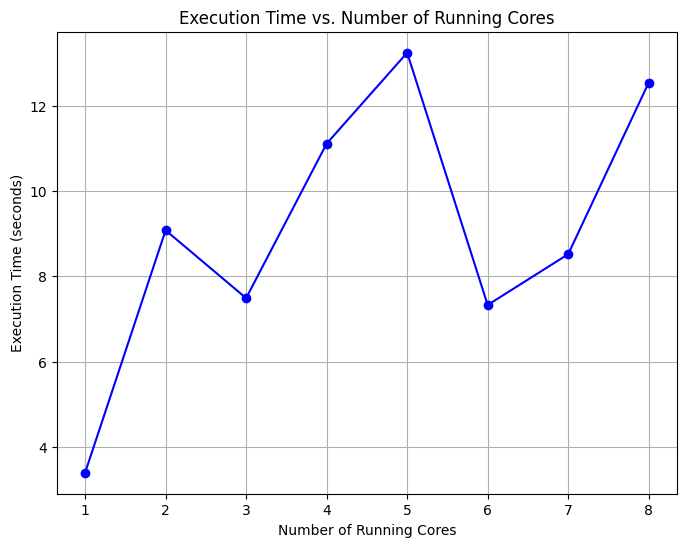

In [10]:
# JaneAusten.txt
# 1 cpu -> 3.40s
# 2 cpu -> 9.08s
# 3 cpu -> 7.49s
# 4 cpu -> 11.11s
# 5 cpu -> 13.24s
# 6 cpu -> 7.33s
# 7 cpu -> 8.52s
# 8 cpu -> 12.54s

import matplotlib.pyplot as plt

execution_time = [3.40, 9.08, 7.49, 11.11, 13.24, 7.33, 8.52, 12.54]
number_of_cores = [1, 2, 3, 4, 5, 6, 7, 8]

plt.figure(figsize=(8, 6))
plt.plot(number_of_cores, execution_time, marker='o', linestyle='-', color='b')
plt.title("Execution Time vs. Number of Running Cores")
plt.xlabel("Number of Running Cores")
plt.ylabel("Execution Time (seconds)")

plt.grid(True)
plt.show()


In [ ]:
# Specifying the paths for the input and output files
input_file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
output_file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"

# Reading the content of the original file
original_text = sc.textFile(input_file_path)

# Defining the number of times you want to repeat the content
repeat_times = 50

# Concatenating the original content multiple times into a single RDD
repeated_text_rdd = original_text.flatMap(lambda line: [line] * repeat_times)

# Collecting the content as a list
concatenated_content = repeated_text_rdd.collect()

# Joining the list elements into a single string
concatenated_text = "\n".join(concatenated_content)

# Saving the concatenated text to a single text file
with open(output_file_path, "w") as output_file:
    output_file.write(concatenated_text)

In [ ]:
# running with 1 cpu unit
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 75.53 seconds


In [ ]:
# running with 2 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 82.58 seconds


In [ ]:
# running with 3 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 76.53 seconds


In [ ]:
# running with 4 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 87.68 seconds


In [ ]:
# running with 5 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 82.01 seconds


In [8]:
# running with 6 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 86.21 seconds


In [8]:
# running with 7 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 84.45 seconds


In [8]:
# running with 8 cpu units
# Recording the start time
start_time = time.time()

# Reading the text file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten50.txt"
text_rdd = spark.sparkContext.textFile(file_path)

# Removing HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

text_rdd = text_rdd.map(remove_tags_and_urls)

# Splitting the lines into words and count the occurrences
word_counts = text_rdd.flatMap(lambda line: line.split(" ")).map(lambda word: (word, 1)).reduceByKey(lambda a, b: a + b)

# Defining a function to clean a word
def clean_word(word):
    # Removing excess marks and non-alphanumeric characters
    word = re.sub(r'[^a-zA-Z]', ' ', word)
    # Removing leading and trailing whitespace
    word = word.strip()
    # Converting to lowercase
    word = word.lower()
    return word

# Applying the cleaning function to each word
cleaned_word_counts_list = [(clean_word(word), count) for word, count in word_counts.collect()]

# Filtering out words that are empty after cleaning
cleaned_word_counts_list = [(word, count) for word, count in cleaned_word_counts_list if word.strip() != ""]

final_cleaned_word_counts_list = []
for word, count in cleaned_word_counts_list:
    words = word.split()  # Splitting by spaces
    words = [w for w in words if w]  # Removing empty strings
    final_cleaned_word_counts_list.extend([(w, count) for w in words])

# Removing stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
final_cleaned_word_counts_list = [(word, count) for word, count in final_cleaned_word_counts_list if word not in stop_words]

# Reducing the word_counts_list by key
reduced_word_counts = spark.sparkContext.parallelize(final_cleaned_word_counts_list).reduceByKey(lambda a, b: a + b)

# Collecting the results as a list
word_counts_list = reduced_word_counts.collect()

# Filtering words with a count of 1
unique_words = [word for word, count in word_counts_list if count == 1]

# Calculating the number of unique words
num_unique_words = len(unique_words)

# Printing the number of unique words
print(f"Number of unique words (words that occurred only once): {num_unique_words}")

# Printing the list of unique words
print("List of words that occurred only once:")

for word in unique_words:
  print(word)

# Recording the end time
end_time = time.time()

# Calculating the elapsed time in seconds and centiseconds
elapsed_time_seconds = end_time - start_time

print(f"Elapsed time: {elapsed_time_seconds:.2f} seconds")


Number of unique words (words that occurred only once): 0
List of words that occurred only once:
Elapsed time: 82.43 seconds


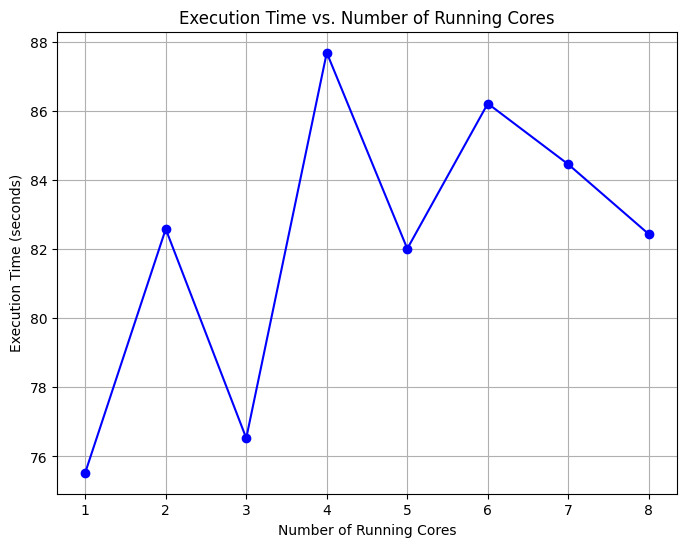

In [9]:
# JaneAusten50.txt
# 1 cpu -> 75.53s
# 2 cpu -> 82.58s
# 3 cpu -> 76.53s
# 4 cpu -> 87.68s
# 5 cpu -> 82.01s
# 6 cpu -> 86.21s
# 7 cpu -> 84.45s
# 8 cpu -> 82.43s

import matplotlib.pyplot as plt

execution_time = [75.53, 82.58, 76.53, 87.68, 82.01, 86.21, 84.45, 82.43]
number_of_cores = [1, 2, 3, 4, 5, 6, 7, 8]

plt.figure(figsize=(8, 6))
plt.plot(number_of_cores, execution_time, marker='o', linestyle='-', color='b')
plt.title("Execution Time vs. Number of Running Cores")
plt.xlabel("Number of Running Cores")
plt.ylabel("Execution Time (seconds)")

plt.grid(True)
plt.show()


In [11]:
import os
os.environ['PYTHONHASHSEED'] = '0'

# Loading the "JaneAusten.txt" file
file_path = "/content/drive/My Drive/Colab Notebooks/big_data_codes/JaneAusten.txt"
sentences = sc.textFile(file_path) \
    .glom() \
    .map(lambda x: " ".join(x)) \
    .flatMap(lambda x: re.split(r'(?<=[.!?])\s+', x))  # Split text into sentences

# Function to count the number of words in a sentence
def count_words(sentence):
    words = sentence.split()
    return (5 if len(words) == 5 else 10, 1)

# Processing sentences to count 5-word and 10-word sentences
sentence_counts = sentences.map(count_words).reduceByKey(lambda a, b: a + b)

# Printing the results
print("Number of 5-word sentences:", sentence_counts.lookup(5)[0])
print("Number of 10-word sentences:", sentence_counts.lookup(10)[0])


Number of 5-word sentences: 1115
Number of 10-word sentences: 32183


In [12]:
from pyspark.sql import Row

# Showing the 5-word and 10-word sentences with their count of occurrence
def show_sentences_with_counts(sentence_length, count):
    relevant_sentences = sentences.filter(lambda sentence: len(sentence.split()) == sentence_length)
    sentences_and_counts = relevant_sentences.zipWithIndex().filter(lambda x: x[1] < count).keys()
    return sentences_and_counts.collect()

# Creating a dataframe for 5-word sentences
five_word_sentences = show_sentences_with_counts(5, sentence_counts.lookup(5)[0])
five_word_df = spark.createDataFrame([Row(sentence=s, count=1) for s in five_word_sentences])

# Creating a dataframe for 10-word sentences
ten_word_sentences = show_sentences_with_counts(10, sentence_counts.lookup(10)[0])
ten_word_df = spark.createDataFrame([Row(sentence=s, count=1) for s in ten_word_sentences])

# Grouping by sentence and count the occurrences
five_word_df = five_word_df.groupBy("sentence").count()
ten_word_df = ten_word_df.groupBy("sentence").count()

# Showing the dataframes
print("5-word sentences with their count of occurrence:")
five_word_df.show(truncate=False)

print("\n10-word sentences with their count of occurrence:")
ten_word_df.show(truncate=False)

5-word sentences with their count of occurrence:
+----------------------------------+-----+
|sentence                          |count|
+----------------------------------+-----+
|I shall write to Mrs.             |1    |
|This moment, if you please.       |1    |
|There's for you, my dear!         |1    |
|Remember me kindly to her.        |1    |
|"Wentworth was the very name!     |1    |
|Do not think about that.          |1    |
|You _have_ tastes in common.      |1    |
|Perry had been to Mrs.            |1    |
|His wishes have been answered.    |1    |
|But it is always so.              |1    |
|And the dried cherries too!       |1    |
|Most grievously was she humbled.  |1    |
|You did look remarkably well.     |1    |
|But what shall I say?             |1    |
|Cole should have done it.         |1    |
|Find some body for me.            |1    |
|Bingley called again, and alone.  |1    |
|Nothing was wanting on Mrs.       |1    |
|You must write to me.             |1    |
|Her 

# 1-2

In [ ]:
from pyspark.ml.feature import Tokenizer
from pyspark.ml.feature import Word2Vec
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import StopWordsRemover
from pyspark.sql import Row

# Loading the files
file_path1 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/Alice_in_Wonderland.txt"
file_path2 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/Adventures_of_Sherlock_Holmes.txt"
file_path3 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/Jane_Eyre.txt"
file_path4 = "/content/drive/My Drive/Colab Notebooks/big_data_codes/Dracula_bromstoker.txt"

# Function to remove HTML tags and URLs
def remove_tags_and_urls(line):
    line = re.sub('<.*?>', ' ', line)  # Remove HTML tags
    line = re.sub('https?://\S+|www\.\S+', '', line)  # Remove URLs
    return line

# Loading text from RDD and create DataFrames
text_rdd1 = spark.sparkContext.textFile(file_path1).map(remove_tags_and_urls)
text_rdd2 = spark.sparkContext.textFile(file_path2).map(remove_tags_and_urls)
text_rdd3 = spark.sparkContext.textFile(file_path3).map(remove_tags_and_urls)
text_rdd4 = spark.sparkContext.textFile(file_path4).map(remove_tags_and_urls)

# Converting RDD to DataFrames
text_df1 = text_rdd1.map(lambda x: Row(value=x))
text_df2 = text_rdd2.map(lambda x: Row(value=x))
text_df3 = text_rdd3.map(lambda x: Row(value=x))
text_df4 = text_rdd4.map(lambda x: Row(value=x))

# Creating DataFrames
df1 = spark.createDataFrame(text_df1)
df2 = spark.createDataFrame(text_df2)
df3 = spark.createDataFrame(text_df3)
df4 = spark.createDataFrame(text_df4)

# Tokenizing the text in both DataFrames
tokenizer = Tokenizer(inputCol="value", outputCol="words")
tokenized_df1 = tokenizer.transform(df1)
tokenized_df2 = tokenizer.transform(df2)
tokenized_df3 = tokenizer.transform(df3)
tokenized_df4 = tokenizer.transform(df4)

# Removing stop words
remover = StopWordsRemover(inputCol="words", outputCol="filtered")
filtered_df1 = remover.transform(tokenized_df1)
filtered_df2 = remover.transform(tokenized_df2)
filtered_df3 = remover.transform(tokenized_df3)
filtered_df4 = remover.transform(tokenized_df4)

# Creating Word2Vec models for the text files
word2vec = Word2Vec(vectorSize=100, seed=42, inputCol="filtered", outputCol="features")
model1 = word2vec.fit(filtered_df1)
model2 = word2vec.fit(filtered_df2)
model3 = word2vec.fit(filtered_df3)
model4 = word2vec.fit(filtered_df4)

# Extracting the Word2Vec vectors
vectors1 = model1.transform(filtered_df1).select("features").collect()[0][0]
vectors2 = model2.transform(filtered_df2).select("features").collect()[0][0]
vectors3 = model3.transform(filtered_df3).select("features").collect()[0][0]
vectors4 = model4.transform(filtered_df4).select("features").collect()[0][0]

# Calculating Cosine Similarity
similarity_12 = Vectors.dense(vectors1).dot(Vectors.dense(vectors2)) / (Vectors.dense(vectors1).norm(2) * Vectors.dense(vectors2).norm(2))
similarity_13 = Vectors.dense(vectors1).dot(Vectors.dense(vectors3)) / (Vectors.dense(vectors1).norm(2) * Vectors.dense(vectors3).norm(2))
similarity_14 = Vectors.dense(vectors1).dot(Vectors.dense(vectors4)) / (Vectors.dense(vectors1).norm(2) * Vectors.dense(vectors4).norm(2))
similarity_23 = Vectors.dense(vectors2).dot(Vectors.dense(vectors3)) / (Vectors.dense(vectors2).norm(2) * Vectors.dense(vectors3).norm(2))
similarity_24 = Vectors.dense(vectors2).dot(Vectors.dense(vectors4)) / (Vectors.dense(vectors2).norm(2) * Vectors.dense(vectors4).norm(2))
similarity_34 = Vectors.dense(vectors3).dot(Vectors.dense(vectors4)) / (Vectors.dense(vectors3).norm(2) * Vectors.dense(vectors4).norm(2))

# Converting the similarity to a percentage
similarity_percentage_12 = (1.0 + similarity_12) / 2.0 * 100.0
similarity_percentage_13 = (1.0 + similarity_13) / 2.0 * 100.0
similarity_percentage_14 = (1.0 + similarity_14) / 2.0 * 100.0
similarity_percentage_23 = (1.0 + similarity_23) / 2.0 * 100.0
similarity_percentage_24 = (1.0 + similarity_24) / 2.0 * 100.0
similarity_percentage_34 = (1.0 + similarity_34) / 2.0 * 100.0


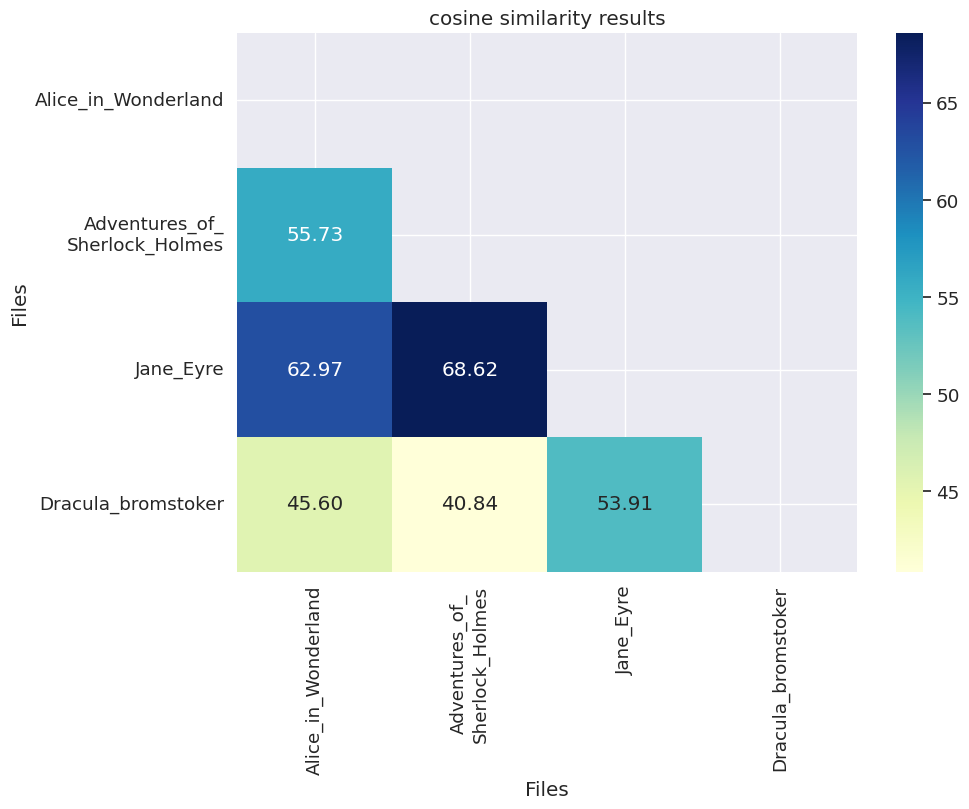

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have the similarity percentages for pairs of files as described
similarity_matrix = [
    [0, 0, 0, 0],
    [similarity_percentage_12, 0, 0, 0],
    [similarity_percentage_13, similarity_percentage_23, 0, 0],
    [similarity_percentage_14, similarity_percentage_24, similarity_percentage_34, 0]
]

# Labels for the files
file_labels = ['Alice_in_Wonderland', 'Adventures_of_\nSherlock_Holmes', 'Jane_Eyre', 'Dracula_bromstoker']

# Creating a mask for 0 values
mask = np.zeros_like(similarity_matrix)
mask[np.triu_indices_from(mask)] = True

# Creating a heatmap
plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2)  # Adjust font size if needed
sns.heatmap(similarity_matrix, mask=mask, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=file_labels, yticklabels=file_labels)

# Setting axis labels and plot title
plt.xlabel("Files")
plt.ylabel("Files")
plt.title("cosine similarity results")

# Showing the plot
plt.show()
